<a href="https://colab.research.google.com/github/aymuos/endgame/blob/main/07_reward_oracle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Notebook Snapshot: Reward Oracle for Bandits Simulator

**1. Objective:**
Developed a city-specific reward oracle (delivery duration predictor) for a multi-armed bandit simulator using the LaDe dataset. The goal was to predict 'pre-action' incremental delivery duration.

**2. Data Processing & Feature Engineering:**
*   **Cities:** Chongqing, Shanghai, and Hangzhou.
*   **Static Features:** 27 features (e.g., distance, weather, structural batch info).
*   **Dynamic Features:** Engineered 7 'pre-action' states including `batch_progress`, `elapsed_route_time`, and `dist_from_current`.
*   **Cyclic Encoding:** Applied sin/cos transformations to temporal features to capture diurnal patterns.
*   **Leakage Prevention:** Implemented a batch-wise split (70/10/20) ensuring no training data leakage into validation/test sets.

**3. Modeling Strategy:**
*   **Algorithm:** LightGBM (GBDT) for regression.
*   **Baseline:** Compared against a 'Mean Target' baseline.
*   **Feature Selection Comparison:**
    *   **Full-Features (35):** All static + dynamic features.
    *   **Causal-Only (21-24):** City-specific sets validated by PC algorithm causal discovery.
    *   **SHAP-Top-10 (10):** Top features identified by SHAP values.

**4. Key Performance Insights:**
*   **Predictability:** Models significantly beat baselines (e.g., Shanghai ACC@20: ~78% vs ~53% baseline).
*   **Feature Redundancy:** Reduced models (SHAP-10) maintained a ~0.94 prediction correlation with Full-Feature models, proving that 10 features capture the vast majority of the signal.
*   **Top Predictors:** `courier_eta_ewm`, `dist_from_current`, `remaining_orders`, and `hour_sin_dynamic` emerged as the most important features across cities.
*   **Geographic Challenges:** Chongqing remains the hardest to predict (lowest R²) due to complex 3D topography.

**5. Current State:**
Trained models (PKL format) are saved to Google Drive. The environment is primed for downstream bandit simulation or further interpretability analysis.

In [35]:
local = False

# Configure SIMD before importing NumPy/SciPy when running locally on AVX-512 hardware.
if local:
    import os
    os.environ.setdefault('MKL_ENABLE_INSTRUCTIONS', 'AVX512')
    os.environ.setdefault('OMP_NUM_THREADS', '1')  # joblib owns parallelism
    os.environ.setdefault('OPENBLAS_CORETYPE', 'SKYLAKEX')
    print('Local AVX-512 hints set (MKL_ENABLE_INSTRUCTIONS=AVX512, OPENBLAS_CORETYPE=SKYLAKEX)')

if not local:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
! pip install lightgbm scikit-learn scikit-learn-intelex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 72.7 MB/s eta 0:00:00
  Attempting uninstall: tbb
    Found existing installation: tbb 2022.3.1
    Uninstalling tbb-2022.3.1:
      Successfully uninstalled tbb-2022.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mkl 2025.3.1 requires tbb==2022.*, but you have tbb 2023.1.0 which is incompatible.


In [36]:
if local :
# 1. Apply the AMD acceleration patch FIRST
    # 1. Trigger the AVX-512 level optimizations
    from sklearnex import patch_sklearn
    patch_sklearn()



In [37]:
from pathlib import Path
if local:
    root = Path('data')
    if not root.exists():
        root = Path('.data')
else:
    root = Path('/content/drive/MyDrive/ml/CORRECTEDv3')

DATA_PATHS = {
    'Chongqing': root / 'delivery_features_chongqing.parquet',
    'Shanghai': root / 'delivery_features_shanghai.parquet',
    'Hangzhou': root / 'delivery_features_hangzhou.parquet',
}

OUTPUT_DIR = root / 'causal_graphs' / 'pc_delivery'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [63]:
# this is the full set of features from master_feature_creator notebook

STATIC_FEATURES = [  # 27

    # Structural
    "pickup_destination_distance",
    "batch_size",
    "batch_rank_dispatch",
    "same_aoi_share_in_batch",
    "isolated_delivery",
    "distance_to_batch_centroid",
    "typecode_cb",

    # Operational
    "courier_eta_ewm",
    "gps_points",
    "speed_mean_15m",
    "speed_std_15m",
    "distance_travelled_15m",
    "coverage_ratio",
    "gps_gap_min",
    "idle_fraction",
    "is_trajectory_available",

    # Environment
    "WSI",
    "temperature_2m",
    "precipitation",
    "windspeed_10m",
    "spatial_congestion_daily",
    "spatial_congestion_norm",

    # Time
    "hour_sin",
    "hour_cos",
    "is_weekend",
    "is_holiday",
    "is_holiday_eve"
]



# intermediate bandit states , only for training
DYNAMIC_FEATURES = [   #8

    "dist_from_current",
    "remaining_orders",
    "batch_progress",
    "elapsed_route_time",
    "last_duration",
    "current_hour",
    "cumulative_distance"
]

# Top 10 features determined by SHAP analysis per city
SHAP_FEAT_IMP_SHANGHAI = [
    "courier_eta_ewm",
    "dist_from_current",
    "remaining_orders",
    "elapsed_route_time",
    "hour_sin_dynamic",
    "batch_size",
    "batch_progress",
    "hour_cos_dynamic",
    "last_duration",
    "same_aoi_share_in_batch"
]

SHAP_FEAT_IMP_HANGZHOU = [
    "remaining_orders",
    "dist_from_current",
    "courier_eta_ewm",
    "hour_sin_dynamic",
    "last_duration",
    "batch_progress",
    "elapsed_route_time",
    "batch_size",
    "distance_to_batch_centroid",
    "hour_sin"
]

SHAP_FEAT_IMP_CHONGQING = [
    "remaining_orders",
    "dist_from_current",
    "hour_sin_dynamic",
    "courier_eta_ewm",
    "batch_progress",
    "elapsed_route_time",
    "same_aoi_share_in_batch",
    "last_duration",
    "batch_size",
    "hour_sin"
]

In [49]:
CAUSAL_THRESHOLD_MAP = {
    'Chongqing': {
        0.5: ["batch_size", "courier_eta_ewm", "hour_cos", "hour_sin", "idle_fraction", "pickup_destination_distance", "spatial_congestion_norm", "temperature_2m", "typecode_cb"],
        0.75: ["batch_size", "courier_eta_ewm", "hour_cos", "hour_sin", "pickup_destination_distance", "spatial_congestion_norm", "temperature_2m", "typecode_cb"],
        0.9: ["batch_size", "courier_eta_ewm", "pickup_destination_distance", "spatial_congestion_norm"]
    },
    'Hangzhou': {
        0.5: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "windspeed_10m"],
        0.75: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "windspeed_10m"],
        0.9: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "spatial_congestion_norm", "temperature_2m", "windspeed_10m"]
    },
    'Shanghai': {
        0.5: ["batch_size", "courier_eta_ewm", "hour_sin", "isolated_delivery", "pickup_destination_distance", "precipitation", "same_aoi_share_in_batch", "spatial_congestion_norm", "temperature_2m", "typecode_cb", "windspeed_10m"],
        0.75: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "typecode_cb", "windspeed_10m"],
        0.9: ["batch_size", "courier_eta_ewm", "hour_sin", "pickup_destination_distance", "precipitation", "spatial_congestion_norm", "temperature_2m", "typecode_cb", "windspeed_10m"]
    }
}

print("Causal threshold map defined for Chongqing, Hangzhou, and Shanghai.")

Causal threshold map defined for Chongqing, Hangzhou, and Shanghai.


In [50]:
def get_causal_features(city, threshold=0.5):
    """Retrieves the causal feature list for a specific city and threshold."""
    # Get city specific map
    city_map = CAUSAL_THRESHOLD_MAP.get(city)
    if not city_map:
        print(f"Warning: No causal map found for {city}. Falling back to Shanghai 0.5.")
        return CAUSAL_THRESHOLD_MAP['Shanghai'][0.5]

    # Get features for threshold, defaulting to 0.5 if threshold not found
    features = city_map.get(threshold, city_map[0.5])



    return features

# Example usage:
cq_features = get_causal_features('Chongqing', 0.9)
print(f"Causal features for Chongqing (0.9): {cq_features}")

Causal features for Chongqing (0.9): ['batch_size', 'courier_eta_ewm', 'pickup_destination_distance', 'spatial_congestion_norm']


In [38]:
import pandas as pd

for city, path in DATA_PATHS.items():
    print(f"Processing {city} data...")
    try:
        df = pd.read_parquet(path)
        missing_features = [feature for feature in STATIC_FEATURES if feature not in df.columns]
        if not missing_features:
            print(f"  All STATIC_FEATURES are present in {city} dataframe.")
        else:
            print(f"  The following STATIC_FEATURES are missing in {city} dataframe: {missing_features}")
    except FileNotFoundError:
        print(f"  Error: File not found at {path}")
    except Exception as e:
        print(f"  An error occurred while processing {city} data: {e}")
print("\nFinished checking all dataframes.")

Processing Chongqing data...
  All STATIC_FEATURES are present in Chongqing dataframe.
Processing Shanghai data...
  All STATIC_FEATURES are present in Shanghai dataframe.
Processing Hangzhou data...
  All STATIC_FEATURES are present in Hangzhou dataframe.

Finished checking all dataframes.


## DYNAMIC FEATURE calculation - features needed from main dataset

- batch_id , batch_rank_actual , batch_size , receipt_time and sign_time
- pickup_destination_distance , poi_lng and poi_lat


These are used just to train the model for oracle - not to gauge the accuracy


The objective is :

1. The oracle predicts the duration before the action is taken.

2. The state should therefore represent the system immediately before choosing the next delivery.


In [9]:
import polars as pl

# true dispatch time is not available for all orders in LaDe, so for the first order
# we used the receipt_time. This is a shortcoming and approximation.

# The objective is :

# 1. The oracle predicts the duration before the action is taken.

# 2. The state should therefore represent the system immediately before choosing the next delivery.

def compute_dynamic_features_polars(df: pl.DataFrame) -> pl.DataFrame:
    # Ensure datetime columns are in datetime format
    df = df.with_columns([
        pl.col('receipt_time').cast(pl.Datetime),
        pl.col('sign_time').cast(pl.Datetime)
    ])

    # Sort by batch_id and batch_rank_actual (0-indexed)
    sort_keys = ['batch_id', 'batch_rank_actual']
    df_sorted = df.sort(sort_keys)

    # 1. remaining_orders = total batch size - orders already delivered
    # At rank 0, we have 'batch_size' orders left to deliver.
    df_sorted = df_sorted.with_columns(
        (pl.col('batch_size').cast(pl.Int64) - pl.col('batch_rank_actual').cast(pl.Int64)).alias('remaining_orders')
    )

    # 2. batch_progress = batch_rank_actual / batch_size
    # Represents progress BEFORE the current delivery is completed.

    df_sorted = df_sorted.with_columns(
        (pl.col('batch_rank_actual').cast(pl.Float64) / pl.col('batch_size').cast(pl.Float64))
        .alias('batch_progress')
    )

    # Helper calculations for incremental duration
    duration_from_receipt = (
        (pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes()
        .fill_null(0.0)
        .clip(lower_bound=0)
    )

    duration_from_prev_sign = (
        (pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes()
        .fill_null(0.0)
        .clip(lower_bound=0)
    )

    # 3. Incremental Duration
    df_sorted = df_sorted.with_columns(
        pl.when(pl.col('batch_rank_actual') == 0)
        .then(duration_from_receipt)
        .otherwise(duration_from_prev_sign)
        .alias('incremental_duration')
    )

    # 4. elapsed_route_time (Time elapsed BEFORE the current leg starts)
    df_sorted = df_sorted.with_columns(
        (pl.col('incremental_duration').cum_sum().over('batch_id') - pl.col('incremental_duration')).alias('elapsed_route_time')
    )

    # 5. Current Hour (Fractional hour at the start of this leg)
    df_sorted = df_sorted.with_columns(
        (pl.col('receipt_time') + pl.duration(minutes=pl.col('elapsed_route_time'))).alias('current_time')
    )
    df_sorted = df_sorted.with_columns(
        (pl.col('current_time').dt.hour() + pl.col('current_time').dt.minute().cast(pl.Float64)/60).alias('current_hour')
    )

    # 6. last_duration (Fixed order: shift -> over -> fill_null)
    df_sorted = df_sorted.with_columns(
        pl.col('incremental_duration')
        .shift(1)
        .over('batch_id')
        .fill_null(0.0)
        .alias('last_duration')
    )

    # 7. dist_from_current (Fixed order: shift -> over)
    df_sorted = df_sorted.with_columns([
        pl.col('poi_lng').shift(1).over('batch_id').alias('prev_lng'),
        pl.col('poi_lat').shift(1).over('batch_id').alias('prev_lat')
    ])

    df_sorted = df_sorted.with_columns(
        (
            ((pl.col('poi_lng') - pl.col('prev_lng'))**2 + (pl.col('poi_lat') - pl.col('prev_lat'))**2).sqrt()
        )
        .fill_null(pl.col('pickup_destination_distance'))
        .alias('dist_from_current')
    )

    # 8. cumulative_distance (Distance covered BEFORE this leg)
    df_sorted = df_sorted.with_columns(
        (pl.col('dist_from_current').cum_sum().over('batch_id') - pl.col('dist_from_current')).alias('cumulative_distance')
    )

    # Clean up temporary columns
    df_final = df_sorted.drop(['current_time', 'prev_lng', 'prev_lat', 'incremental_duration'])
    return df_final

processed_dfs = {}
for city, path in DATA_PATHS.items():
    print(f"\nProcessing {city} data...")
    try:
        df = pl.read_parquet(path)
        processed_df = compute_dynamic_features_polars(df)
        processed_dfs[city] = processed_df
        print(f"Finished {city}. 'Pre-action' logic applied")
    except Exception as e:
        print(f"Error processing {city}: {e}")


Processing Chongqing data...
Finished Chongqing. 'Pre-action' logic applied

Processing Shanghai data...
Finished Shanghai. 'Pre-action' logic applied

Processing Hangzhou data...
Finished Hangzhou. 'Pre-action' logic applied


In [40]:
# VERIFICATION CELL -- Using the Chongqing processed dataframe to verify incremental durations
city_sample = 'Chongqing'
if city_sample in processed_dfs:
    # We need to re-calculate incremental_duration briefly for display
    # since it was dropped at the end of the processing function
    df_check = processed_dfs[city_sample]

    # Pick a sample batch to inspect
    sample_bid = df_check.filter(pl.col('batch_size') > 1)['batch_id'][0]

    # Displaying the logic for the specific batch
    check_display = (df_check
        .filter(pl.col('batch_id') == sample_bid)
        .select([
            'batch_id',
            'batch_rank_actual',
            'last_duration',
            'elapsed_route_time'
        ])
    )
    print(f"Checking Batch: {sample_bid}")
    print(check_display)

Checking Batch: 0008c2b6a2314db8715301b7eeeebc5a__37e976ad4abb10da92c97c6b34f7f54f__318__1616055600
shape: (8, 4)
┌─────────────────────────────────┬───────────────────┬───────────────┬────────────────────┐
│ batch_id                        ┆ batch_rank_actual ┆ last_duration ┆ elapsed_route_time │
│ ---                             ┆ ---               ┆ ---           ┆ ---                │
│ str                             ┆ u32               ┆ f64           ┆ f64                │
╞═════════════════════════════════╪═══════════════════╪═══════════════╪════════════════════╡
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 0                 ┆ 0.0           ┆ 0.0                │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 1                 ┆ 85.0          ┆ 85.0               │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 2                 ┆ 97.0          ┆ 182.0              │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 3                 ┆ 25.0          ┆ 207.0              │
│ 0008c2b6a2314db8715301b7eeeebc… ┆ 4            

In [41]:
# SANITY CHECK COLUMN - NEED NOT RUN
import polars as pl

# Re-running the core logic for Chongqing to inspect df_sorted before final cleanup
city_to_check = 'Chongqing'
raw_df = pl.read_parquet(DATA_PATHS[city_to_check])

# Standard preprocessing inside the function logic
df_check = raw_df.with_columns([
    pl.col('receipt_time').cast(pl.Datetime),
    pl.col('sign_time').cast(pl.Datetime)
]).sort(['batch_id', 'batch_rank_actual'])

duration_from_receipt = (
    (pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes()
    .fill_null(0.0)
    .clip(lower_bound=0)
)

duration_from_prev_sign = (
    (pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes()
    .fill_null(0.0)
    .clip(lower_bound=0)
)

df_sorted_debug = df_check.with_columns(
    pl.when(pl.col('batch_rank_actual') == 0)
    .then(duration_from_receipt)
    .otherwise(duration_from_prev_sign)
    .alias('incremental_duration')
)

# Checking for nulls in incremental_duration and displaying the requested columns
null_count = df_sorted_debug.select(pl.col('incremental_duration').is_null().sum()).item()
print(f"Null count in incremental_duration: {null_count}")

print("First 50 rows of calculation check:")
display(df_sorted_debug.select([
    "batch_id",
    "batch_rank_actual",
    "incremental_duration"
]).head(50))

Null count in incremental_duration: 0
First 50 rows of calculation check:


batch_id,batch_rank_actual,incremental_duration
str,u32,f64
"""0008c2b6a2314db8715301b7eeeebc…",0,85.0
"""0008c2b6a2314db8715301b7eeeebc…",1,97.0
"""0008c2b6a2314db8715301b7eeeebc…",2,25.0
"""0008c2b6a2314db8715301b7eeeebc…",3,27.0
"""0008c2b6a2314db8715301b7eeeebc…",4,27.0
…,…,…
"""0008c2b6a2314db8715301b7eeeebc…",0,1.0
"""0008c2b6a2314db8715301b7eeeebc…",0,39.0
"""0008c2b6a2314db8715301b7eeeebc…",1,21.0


In [42]:
# Verification check for 0-indexed rank logic NO NEED TO RUN FOR NORMAL FLOW
city_sample = 'Chongqing'
if city_sample in processed_dfs:
    df_check = processed_dfs[city_sample]
    # Look at a specific batch with more than 1 order to verify ranges
    multi_order_batches = df_check.filter(pl.col('batch_size') > 1).select('batch_id').unique().head(1)
    if not multi_order_batches.is_empty():
        bid = multi_order_batches.item()
        print(f"Verification for Batch ID: {bid}")
        print(df_check.filter(pl.col('batch_id') == bid).select([
            'batch_id', 'batch_size', 'batch_rank_actual', 'remaining_orders', 'batch_progress'
        ]))

Verification for Batch ID: 0008c2b6a2314db8715301b7eeeebc5a__37e976ad4abb10da92c97c6b34f7f54f__318__1616055600
shape: (8, 5)
┌─────────────────────────────┬────────────┬───────────────────┬──────────────────┬────────────────┐
│ batch_id                    ┆ batch_size ┆ batch_rank_actual ┆ remaining_orders ┆ batch_progress │
│ ---                         ┆ ---        ┆ ---               ┆ ---              ┆ ---            │
│ str                         ┆ u32        ┆ u32               ┆ i64              ┆ f64            │
╞═════════════════════════════╪════════════╪═══════════════════╪══════════════════╪════════════════╡
│ 0008c2b6a2314db8715301b7eee ┆ 8          ┆ 0                 ┆ 8                ┆ 0.0            │
│ ebc…                        ┆            ┆                   ┆                  ┆                │
│ 0008c2b6a2314db8715301b7eee ┆ 8          ┆ 1                 ┆ 7                ┆ 0.125          │
│ ebc…                        ┆            ┆                   ┆   

In [43]:
import polars as pl
# Inspect columns to find the batch identifier
for city, path in DATA_PATHS.items():
    df_cols = pl.read_parquet(path).columns
    print(f"{city} columns: {df_cols}")
    break # Just check one to identify the column name

Chongqing columns: ['order_id', 'from_dipan_id', 'delivery_user_id', 'poi_lng', 'poi_lat', 'aoi_id', 'typecode', 'receipt_time', 'receipt_lng', 'receipt_lat', 'sign_time', 'ds', 'eta_mins', 'pickup_destination_distance', 'batch_size', 'isolated_delivery', 'same_aoi_share_in_batch', 'batch_rank_dispatch', 'batch_rank_actual', 'batch_id', 'distance_to_batch_centroid', 'gps_points', 'speed_mean_15m', 'speed_std_15m', 'distance_travelled_15m', 'idle_fraction', 'coverage_ratio', 'ds_right', 'last_gps_time', 'last_x', 'last_y', 'gps_gap_min', 'courier_eta_ewm', 'remaining_haul_distance', 'is_trajectory_available', 'hour', 'weekday', 'receipt_date', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'is_holiday_eve', 'typecode_grouped_missing', 'typecode_grouped_other', 'typecode_grouped_type_1', 'typecode_grouped_type_2', 'typecode_cb', 'grid_x', 'grid_y', 'time_window', 'spatial_congestion_daily', 'spatial_congestion_norm', 'city_right', 'datetime', 'temperature_2m', 'precipitation', 'rain

## Sanity Check:

For the dynamic features , we created we want to check the following crieterias ,

For every batch we should verify:

- incremental_duration >= 0
- elapsed_route_time is monotonic increasing
- last_duration equals the previous row's incremental_duration
- remaining_orders decreases by exactly one at each step
- batch_progress increases monotonically from 0 toward 1
- cumulative_distance never decreases

In [44]:
def validate_batch_logic(df: pl.DataFrame, city_name: str):
    print(f"\n>>> Deep Sanity Check: {city_name} <<<")

    # We need to temporarily recreate incremental_duration for the check
    # as it was dropped in the final processing step
    df_check = df.with_columns([
        pl.when(pl.col('batch_rank_actual') == 0)
        .then((pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes())
        .otherwise((pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes())
        .alias('_inc_dur')
    ])

    # 1. incremental_duration >= 0
    neg_dur = df_check.filter(pl.col('_inc_dur') < 0).height

    # 2. elapsed_route_time is monotonic increasing
    # 6. cumulative_distance never decreases
    # We check if the difference between current and previous is negative
    temporal_anomalies = df_check.filter(
        (pl.col('elapsed_route_time') < pl.col('elapsed_route_time').shift(1).over('batch_id')) |
        (pl.col('cumulative_distance') < pl.col('cumulative_distance').shift(1).over('batch_id'))
    ).height

    # 3. last_duration equals the previous row's incremental_duration
    # Note: rank 0 has no previous, so we skip it
    last_dur_mismatch = df_check.filter(
        (pl.col('batch_rank_actual') > 0) &
        (pl.col('last_duration') != pl.col('_inc_dur').shift(1).over('batch_id'))
    ).height

    # 4. remaining_orders decreases by exactly one
    rank_logic_err = df_check.filter(
        (pl.col('batch_rank_actual') > 0) &
        (pl.col('remaining_orders') != (pl.col('remaining_orders').shift(1).over('batch_id') - 1))
    ).height

    # 5. batch_progress increases monotonically
    progress_err = df_check.filter(
        (pl.col('batch_rank_actual') > 0) &
        (pl.col('batch_progress') <= pl.col('batch_progress').shift(1).over('batch_id'))
    ).height

    print(f"  - Total Records Checked: {df.height}")
    print(f"  - Negative Durations: {neg_dur}")
    print(f"  - Temporal/Distance Monotonicity Violations: {temporal_anomalies}")
    print(f"  - 'last_duration' Mismatches: {last_dur_mismatch}")
    print(f"  - Rank/Remaining Order Inconsistencies: {rank_logic_err}")
    print(f"  - Progress Monotonicity Violations: {progress_err}")

for city, df_processed in processed_dfs.items():
    validate_batch_logic(df_processed, city)


>>> Deep Sanity Check: Chongqing <<<
  - Total Records Checked: 25335
  - Negative Durations: 0
  - Temporal/Distance Monotonicity Violations: 0
  - 'last_duration' Mismatches: 0
  - Rank/Remaining Order Inconsistencies: 0
  - Progress Monotonicity Violations: 0

>>> Deep Sanity Check: Shanghai <<<
  - Total Records Checked: 34480
  - Negative Durations: 0
  - Temporal/Distance Monotonicity Violations: 0
  - 'last_duration' Mismatches: 0
  - Rank/Remaining Order Inconsistencies: 0
  - Progress Monotonicity Violations: 0

>>> Deep Sanity Check: Hangzhou <<<
  - Total Records Checked: 40348
  - Negative Durations: 0
  - Temporal/Distance Monotonicity Violations: 0
  - 'last_duration' Mismatches: 0
  - Rank/Remaining Order Inconsistencies: 0
  - Progress Monotonicity Violations: 0


# Split data into bins keeping batches together

In [45]:
import numpy as np
import polars as pl

city_splits = {}
ALL_FEATURES = STATIC_FEATURES + DYNAMIC_FEATURES
TARGET = "incremental_duration"

for city, df_p in processed_dfs.items():
    print(f"Splitting {city} dataset...")

    # Preserve eta_mins for baseline comparison later
    df_city_final = df_p.with_columns([
        pl.when(pl.col('batch_rank_actual') == 0)
        .then((pl.col('sign_time') - pl.col('receipt_time')).dt.total_minutes())
        .otherwise((pl.col('sign_time') - pl.col('sign_time').shift(1).over('batch_id')).dt.total_minutes())
        .alias(TARGET)
    ]).select(['batch_id', 'eta_mins'] + ALL_FEATURES + [TARGET])

    batch_ids = df_city_final["batch_id"].unique().to_list()
    rng = np.random.default_rng(42)
    rng.shuffle(batch_ids)

    n = len(batch_ids)
    train_end, valid_end = int(0.7 * n), int(0.8 * n)

    train_batches = set(batch_ids[:train_end])
    valid_batches = set(batch_ids[train_end:valid_end])
    test_batches  = set(batch_ids[valid_end:])

    city_splits[city] = {
        "train": df_city_final.filter(pl.col("batch_id").is_in(train_batches)),
        "valid": df_city_final.filter(pl.col("batch_id").is_in(valid_batches)),
        "test": df_city_final.filter(pl.col("batch_id").is_in(test_batches))
    }
    print(f"  {city} split complete.")

Splitting Chongqing dataset...
  Chongqing split complete.
Splitting Shanghai dataset...
  Shanghai split complete.
Splitting Hangzhou dataset...
  Hangzhou split complete.


## Verification that no two batches overlap

In [28]:
for city, splits in city_splits.items():
    train_batches = set(splits['train']['batch_id'].unique())
    valid_batches = set(splits['valid']['batch_id'].unique())
    test_batches = set(splits['test']['batch_id'].unique())

    # Calculate intersections
    tv_overlap = train_batches.intersection(valid_batches)
    vt_overlap = valid_batches.intersection(test_batches)
    tt_overlap = train_batches.intersection(test_batches)

    print(f"--- Leakage Check for {city} ---")
    print(f"  Train/Valid Overlap: {len(tv_overlap)} batches")
    print(f"  Valid/Test Overlap: {len(vt_overlap)} batches")
    print(f"  Train/Test Overlap: {len(tt_overlap)} batches")

    # Verify that total unique batches match
    total_unique = len(train_batches) + len(valid_batches) + len(test_batches)
    actual_unique = len(processed_dfs[city]['batch_id'].unique())
    print(f"  Total Unique Batches accounted for: {total_unique == actual_unique}")

--- Leakage Check for Chongqing ---
  Train/Valid Overlap: 0 batches
  Valid/Test Overlap: 0 batches
  Train/Test Overlap: 0 batches
  Total Unique Batches accounted for: True
--- Leakage Check for Shanghai ---
  Train/Valid Overlap: 0 batches
  Valid/Test Overlap: 0 batches
  Train/Test Overlap: 0 batches
  Total Unique Batches accounted for: True
--- Leakage Check for Hangzhou ---
  Train/Valid Overlap: 0 batches
  Valid/Test Overlap: 0 batches
  Train/Test Overlap: 0 batches
  Total Unique Batches accounted for: True


In [48]:
import numpy as np
import polars as pl

def apply_cyclic_encoding(splits_dict):
    """Applies sin/cos transformation to current_hour."""
    for city in splits_dict:
        for split in ['train', 'valid', 'test']:
            df = splits_dict[city][split]
            splits_dict[city][split] = df.with_columns([
                (pl.col("current_hour") * (2 * np.pi / 24)).sin().alias("hour_sin_dynamic"),
                (pl.col("current_hour") * (2 * np.pi / 24)).cos().alias("hour_cos_dynamic")
            ])
    return splits_dict

# Apply encoding
city_splits = apply_cyclic_encoding(city_splits)

# Update feature list to include new cyclic features and remove raw current_hour
FINAL_FEATURES = [f for f in ALL_FEATURES if f != "current_hour"] + ["hour_sin_dynamic", "hour_cos_dynamic"]

print(f"Cyclic encoding applied. Features for training: {len(FINAL_FEATURES)}")

Cyclic encoding applied. Features for training: 35


### Strategy Comparison: Static Feature Analysis
In this section, we compare three feature selection strategies using only static features:
1. **Full Set**: All available static features.
2. **Causal Set**: Only features validated by the causal discovery process.
3. **SHAP 99th Percentile**: Features that fall above the 99th percentile of importance in a preliminary full-feature model.

In [64]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

def calculate_acc_20(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) <= 20)

comparison_results = []

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.05,
    'num_leaves': 31
}

# Map for city-specific SHAP features
CITY_SHAP_MAP = {
    'Shanghai': SHAP_FEAT_IMP_SHANGHAI,
    'Hangzhou': SHAP_FEAT_IMP_HANGZHOU,
    'Chongqing': SHAP_FEAT_IMP_CHONGQING
}

for city in ['Chongqing', 'Shanghai', 'Hangzhou']:
    splits = city_splits[city]
    y_train = splits['train'].select(TARGET).to_series().to_numpy()
    y_valid = splits['valid'].select(TARGET).to_series().to_numpy()
    y_test = splits['test'].select(TARGET).to_series().to_numpy()

    strategies = [
        (f"Causal_{t}", CAUSAL_THRESHOLD_MAP[city][t]) for t in [0.5, 0.75, 0.9]
    ]
    strategies.append(("Full_Static", STATIC_FEATURES))
    # Use city-specific SHAP features
    strategies.append(("SHAP_Top_10", CITY_SHAP_MAP[city]))

    for name, features in strategies:
        available_features = [f for f in features if f in splits['train'].columns]
        X_tr = splits['train'].select(available_features).to_pandas()
        X_va = splits['valid'].select(available_features).to_pandas()
        X_te = splits['test'].select(available_features).to_pandas()

        m = lgb.train(
            params,
            lgb.Dataset(X_tr, y_train),
            valid_sets=[lgb.Dataset(X_va, y_valid)],
            num_boost_round=500,
            callbacks=[lgb.early_stopping(30), lgb.log_evaluation(period=0)]
        )

        y_pred = m.predict(X_te)

        comparison_results.append({
            'City': city,
            'Strategy': name,
            'Num_Features': len(available_features),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred),
            'ACC@20': calculate_acc_20(y_test, y_pred)
        })

benchmarking_df = pd.DataFrame(comparison_results)
display(benchmarking_df.sort_values(['City', 'RMSE']))

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[70]	valid_0's rmse: 106.343
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[71]	valid_0's rmse: 106.142
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[80]	valid_0's rmse: 105.86
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[122]	valid_0's rmse: 105.405
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[145]	valid_0's rmse: 98.0432
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[53]	valid_0's rmse: 53.8312
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[71]	valid_0's rmse: 53.8167
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[71]	valid_0's rmse: 53.8167

,City,Strategy,Num_Features,RMSE,MAE,MAPE,R2,ACC@20
4,Chongqing,SHAP_Top_10,10,99.079544,47.152256,2.537166,0.238563,0.502758
1,Chongqing,Causal_0.75,8,107.502421,54.286489,2.955175,0.103599,0.239224
3,Chongqing,Full_Static,27,107.776796,54.526464,2.942133,0.099017,0.261696
0,Chongqing,Causal_0.5,9,107.812319,54.374250,2.967510,0.098423,0.236159
2,Chongqing,Causal_0.9,4,108.347769,55.749605,3.094234,0.089445,0.223493
14,Hangzhou,SHAP_Top_10,10,74.704630,33.114125,1.879092,0.232745,0.603527
13,Hangzhou,Full_Static,27,79.239619,37.602446,2.278923,0.136764,0.472808
12,Hangzhou,Causal_0.9,7,79.631500,37.855140,2.332821,0.128204,0.461216
10,Hangzhou,Causal_0.5,8,79.667756,37.895411,2.330726,0.127410,0.458626
11,Hangzhou,Causal_0.75,8,79.667756,37.895411,2.330726,0.127410,0.458626


--- MAPE Comparison by City and Strategy ---


City,Chongqing,Hangzhou,Shanghai
Strategy,,,
Causal_0.5,2.967510,2.330726,1.706300
Causal_0.75,2.955175,2.330726,1.699783
Causal_0.9,3.094234,2.332821,1.699783
Full_Static,2.942133,2.278923,1.684939
SHAP_Top_10,2.537166,1.879092,1.288773


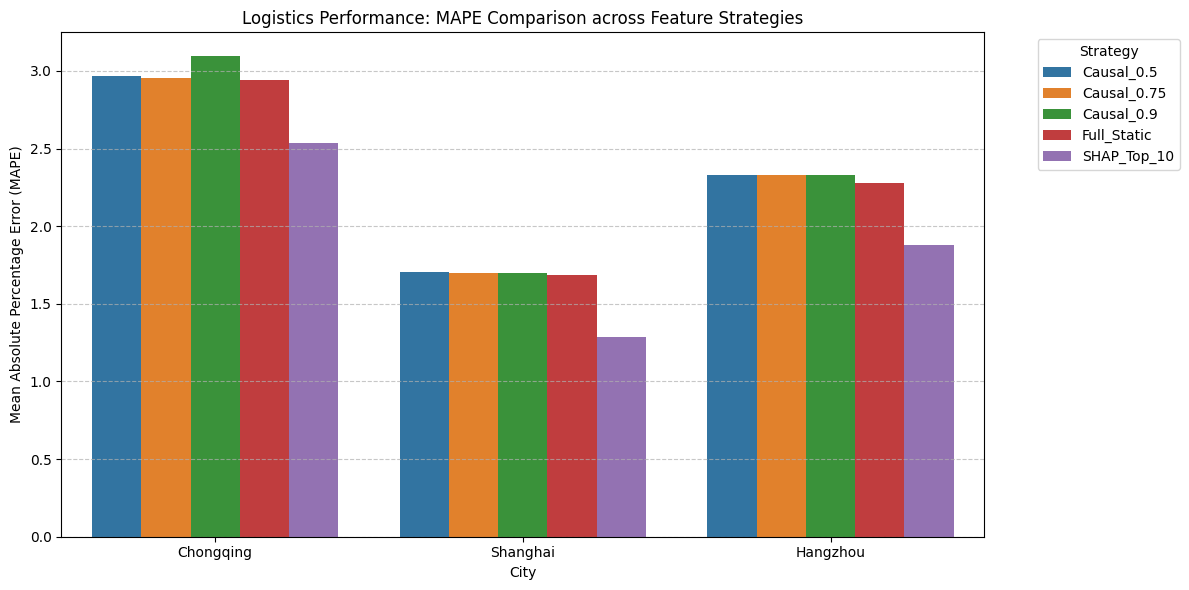


--- Best Performing Strategy per City (Min MAPE) ---
     City    Strategy     MAPE  Num_Features
Chongqing SHAP_Top_10 2.537166            10
 Hangzhou SHAP_Top_10 1.879092            10
 Shanghai SHAP_Top_10 1.288773            10


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display MAPE Comparison Table
mape_comparison = benchmarking_df.pivot(index='Strategy', columns='City', values='MAPE')
print("--- MAPE Comparison by City and Strategy ---")
display(mape_comparison)

# 2. Visualize MAPE across strategies
plt.figure(figsize=(12, 6))
sns.barplot(data=benchmarking_df, x='City', y='MAPE', hue='Strategy')
plt.title('Logistics Performance: MAPE Comparison across Feature Strategies')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.xlabel('City')
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Print Key Logistic Insight
best_mape = benchmarking_df.loc[benchmarking_df.groupby('City')['MAPE'].idxmin()]
print("\n--- Best Performing Strategy per City (Min MAPE) ---")
print(best_mape[['City', 'Strategy', 'MAPE', 'Num_Features']].to_string(index=False))

---

### Final Models: Full vs Causal with Dynamic Features
Training the final production-ready reward oracles for the bandit simulator.

In [66]:
import lightgbm as lgb
import joblib
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_squared_error

# Define the weights directory
WEIGHTS_DIR = Path('/content/drive/MyDrive/ml/CORRECTEDv3/LightGBMweights')
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# Map city names for shorter filenames
city_map = {'Shanghai': 'sh', 'Hangzhou': 'hz', 'Chongqing': 'cq'}

lgbm_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'random_state': 42,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9
}

final_models_benchmarking = []

for city, splits in city_splits.items():
    print(f"\n--- Training Final Models for {city} ---")

    y_train = splits['train'].select(TARGET).to_series().to_numpy()
    y_valid = splits['valid'].select(TARGET).to_series().to_numpy()
    y_test = splits['test'].select(TARGET).to_series().to_numpy()

    # Strategy 1: Full + Dynamic
    # Strategy 2: Causal + Dynamic (Using CAUSAL_FINAL_FEATURES logic)

    # Re-calculate Causal features for this specific city loop
    city_causal_static = get_causal_features(city, threshold=0.5)
    missing_dyn = [f for f in DYNAMIC_FEATURES_LIST if f not in city_causal_static]
    city_causal_full = city_causal_static + missing_dyn + ["hour_sin_dynamic", "hour_cos_dynamic"]

    strategies = [
        ('Full_Dynamic', FINAL_FEATURES),
        ('Causal_Dynamic', city_causal_full)
    ]

    for strategy_name, feature_list in strategies:
        print(f"  Training {strategy_name} ({len(feature_list)} features)...")

        X_tr = splits['train'].select(feature_list).to_pandas()
        X_va = splits['valid'].select(feature_list).to_pandas()
        X_te = splits['test'].select(feature_list).to_pandas()

        train_ds = lgb.Dataset(X_tr, label=y_train)
        valid_ds = lgb.Dataset(X_va, label=y_valid, reference=train_ds)

        model = lgb.train(
            lgbm_params,
            train_ds,
            valid_sets=[valid_ds],
            num_boost_round=1000,
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(period=0)]
        )

        # Save Model
        file_name = f"{city_map[city]}_{strategy_name.lower()}.pkl"
        save_path = WEIGHTS_DIR / file_name
        joblib.dump(model, save_path)

        # Evaluate
        preds = model.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        final_models_benchmarking.append({
            'City': city,
            'Strategy': strategy_name,
            'RMSE': rmse,
            'Num_Features': len(feature_list),
            'Saved_Path': str(save_path)
        })

print("\n--- Final Training Summary ---")
display(pd.DataFrame(final_models_benchmarking))


--- Training Final Models for Chongqing ---
  Training Full_Dynamic (35 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[138]	valid_0's rmse: 98.6734
  Training Causal_Dynamic (17 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[223]	valid_0's rmse: 97.8874

--- Training Final Models for Shanghai ---
  Training Full_Dynamic (35 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[124]	valid_0's rmse: 46.9543
  Training Causal_Dynamic (19 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[112]	valid_0's rmse: 48.079

--- Training Final Models for Hangzhou ---
  Training Full_Dynamic (35 features)...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[119]	valid_0's rmse: 76.591
  Training Causal_Dynamic (16 

,City,Strategy,RMSE,Num_Features,Saved_Path
0,Chongqing,Full_Dynamic,99.049430,35,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
1,Chongqing,Causal_Dynamic,98.892510,17,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
2,Shanghai,Full_Dynamic,56.141082,35,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
3,Shanghai,Causal_Dynamic,55.999854,19,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
4,Hangzhou,Full_Dynamic,73.969581,35,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...
5,Hangzhou,Causal_Dynamic,74.740650,16,/content/drive/MyDrive/ml/CORRECTEDv3/LightGBM...


---

SHAP Analysis


--- SHAP Analysis for Shanghai ---
Top 10 SHAP Features for Shanghai: ['courier_eta_ewm', 'dist_from_current', 'remaining_orders', 'elapsed_route_time', 'hour_sin_dynamic', 'batch_size', 'batch_progress', 'hour_cos_dynamic', 'last_duration', 'same_aoi_share_in_batch']


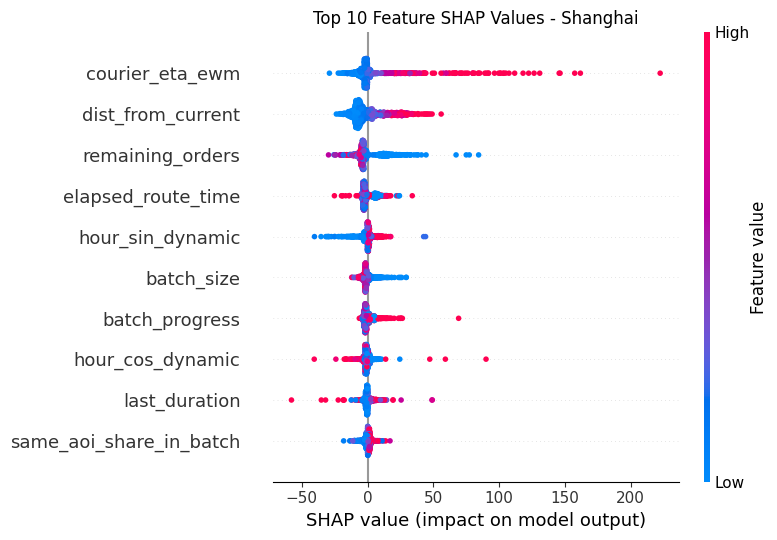


--- SHAP Analysis for Hangzhou ---
Top 10 SHAP Features for Hangzhou: ['remaining_orders', 'dist_from_current', 'courier_eta_ewm', 'hour_sin_dynamic', 'last_duration', 'batch_progress', 'elapsed_route_time', 'batch_size', 'distance_to_batch_centroid', 'hour_sin']


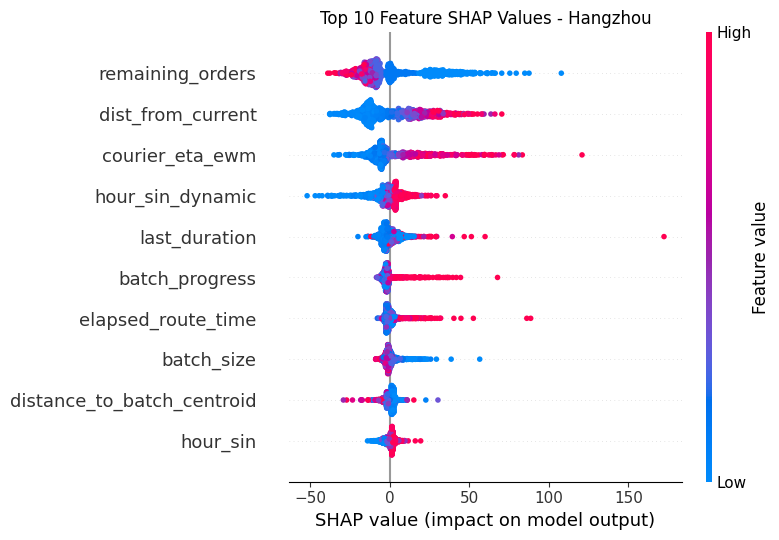


--- SHAP Analysis for Chongqing ---
Top 10 SHAP Features for Chongqing: ['remaining_orders', 'dist_from_current', 'hour_sin_dynamic', 'courier_eta_ewm', 'batch_progress', 'elapsed_route_time', 'same_aoi_share_in_batch', 'last_duration', 'batch_size', 'hour_sin']


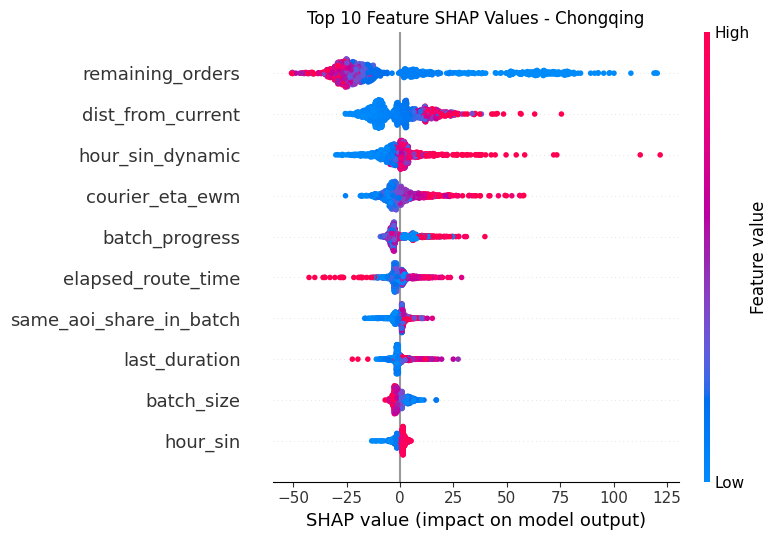

In [61]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Iterate through all cities for SHAP analysis
for city in ['Shanghai', 'Hangzhou', 'Chongqing']:
    print(f"\n--- SHAP Analysis for {city} ---")

    # Get the model and test data for the specific city
    model_shap = models[city]
    X_test_shap = city_splits[city]['test'].select(FINAL_FEATURES).to_pandas()

    # Use TreeExplainer specifically for LightGBM
    explainer = shap.TreeExplainer(model_shap)

    # Sample for performance (1000 records)
    X_sample = X_test_shap.iloc[:1000]
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    # Handle output types (regression models usually return a single array)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[0]
        shap_values_abs = np.abs(shap_values[0]).mean(0)
    else:
        shap_values_to_plot = shap_values
        shap_values_abs = np.abs(shap_values).mean(0)

    # Identify and print top 10 features
    feature_importance = pd.DataFrame(list(zip(FINAL_FEATURES, shap_values_abs)), columns=['col_name','importance'])
    feature_importance = feature_importance.sort_values(by='importance', ascending=False)
    top_10 = feature_importance.head(10)['col_name'].tolist()
    print(f"Top 10 SHAP Features for {city}: {top_10}")

    # Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_to_plot, X_sample, max_display=10, show=False)
    plt.title(f"Top 10 Feature SHAP Values - {city}")
    plt.tight_layout()
    plt.show()

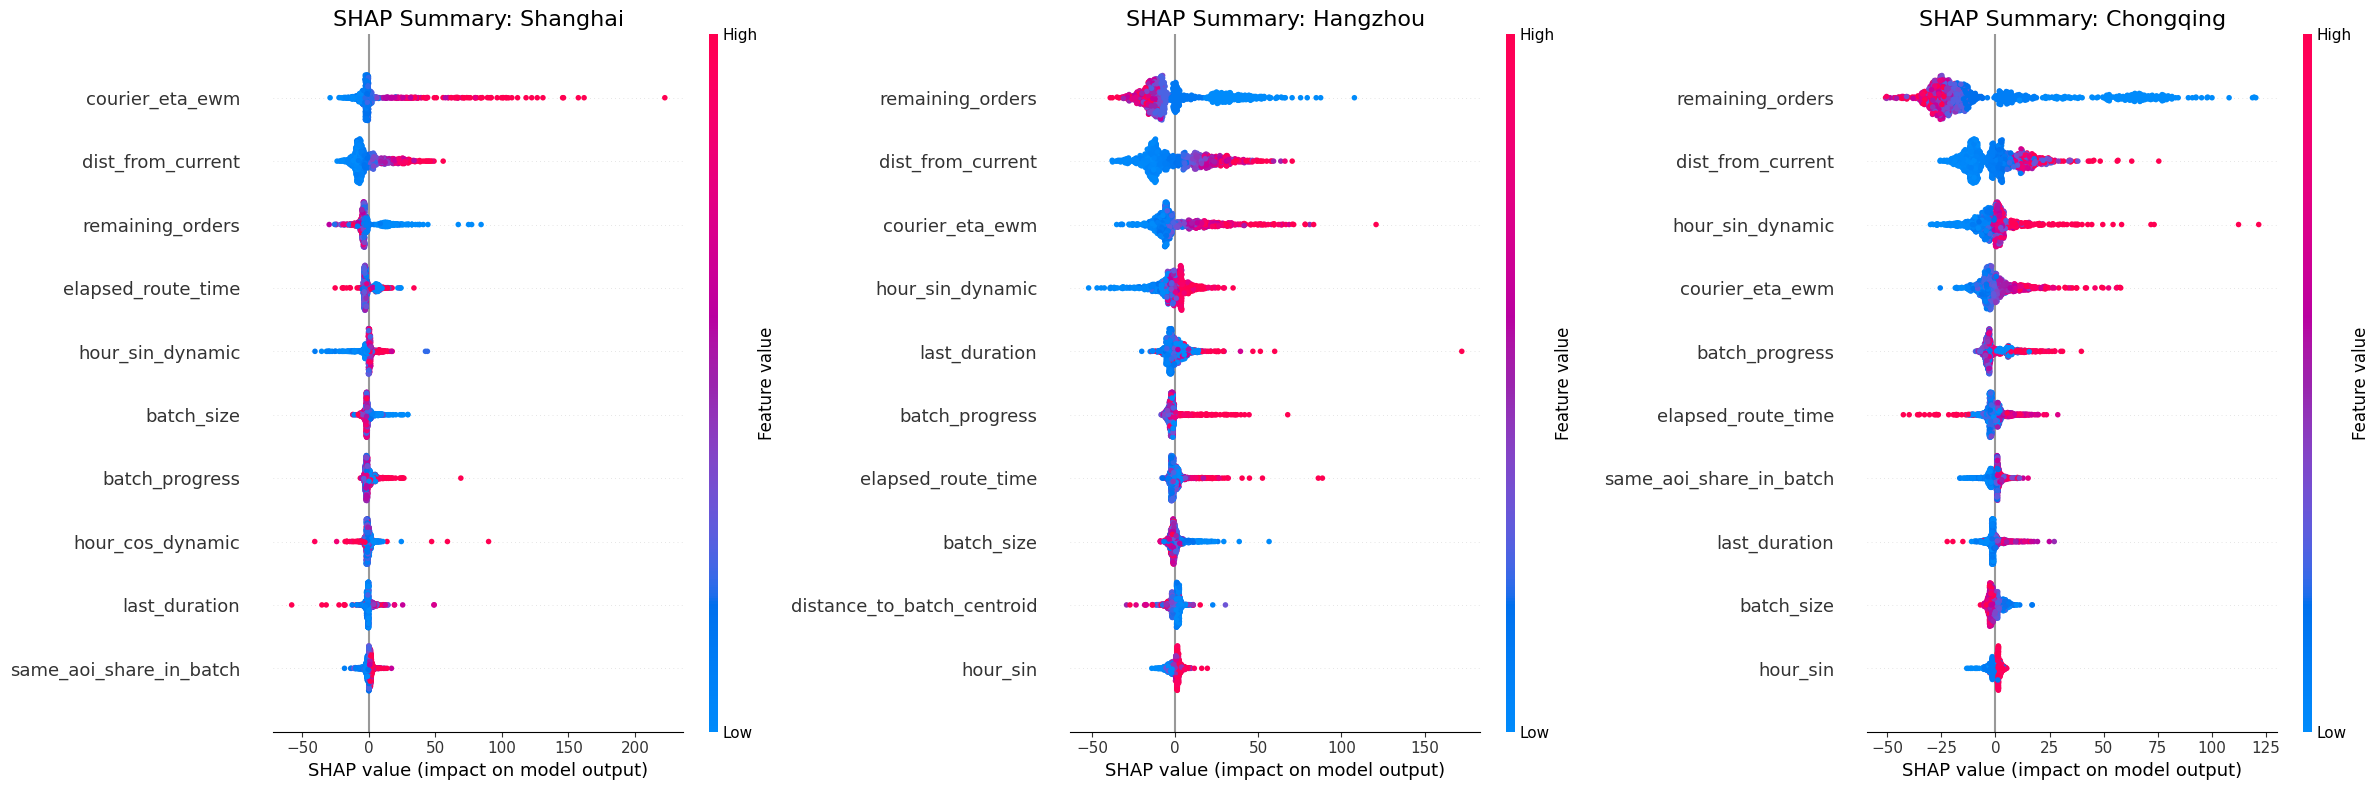

In [62]:
import shap
import matplotlib.pyplot as plt

# Set up a figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
cities = ['Shanghai', 'Hangzhou', 'Chongqing']

for i, city in enumerate(cities):
    # Prepare data
    model_shap = models[city]
    X_test_shap = city_splits[city]['test'].select(FINAL_FEATURES).to_pandas()
    X_sample = X_test_shap.iloc[:1000]

    # Calculate SHAP values
    explainer = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X_sample, check_additivity=False)

    # SHAP summary plots usually manage their own colorbars/axes,
    # so we pass the specific axis to the plot function
    plt.sca(axes[i])
    shap.summary_plot(shap_values, X_sample, max_display=10, show=False, plot_size=None)
    axes[i].set_title(f"SHAP Summary: {city}", fontsize=16)

plt.tight_layout()
plt.show()